# ML Capstone — Review 2
## Member 1 (Adithya) — Clustering Track: Setup + K-Means

**Dataset:** Beijing Multi-Site Air-Quality Data (UCI) — hourly readings from 12 monitoring stations, March 2013 – February 2017

**Algorithm:** K-Means Clustering

**Rule followed:** `station` and `season` are **never** used while fitting. They are kept aside and used only after clustering to interpret the result.

Checkpoint 1 covers: loading, audit, missing-value handling, feature selection, scaling.

## 0. Imports and Settings

In [23]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="colorblind")
PALETTE = sns.color_palette("colorblind")

## 1. Load Dataset

The dataset comes as one CSV per station. We read all 12 and stack them into a single table. Missing values are stored as `NA` in the files and load as `NaN`.

In [24]:
DATA_FILE = "PRSA_Data_Aotizhongxin_20130301-20170228.csv"   # same folder as the notebook
raw = pd.read_csv(DATA_FILE)
print("Shape:", raw.shape)
display(raw.head())

Shape: (35064, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


## 2. Dataset Audit

In [25]:
print("Data types:")
display(raw.dtypes)

miss = raw.isna().sum()
audit = pd.DataFrame({"missing": miss, "missing_%": (miss / len(raw) * 100).round(2)})
print("\nColumns with missing values:")
display(audit[audit["missing"] > 0].sort_values("missing", ascending=False))

dups = raw.duplicated(subset=["year", "month", "day", "hour"]).sum()
print("Duplicate hourly rows:", dups)
print("Period:", raw[["year","month","day"]].min().tolist(), "to", raw[["year","month","day"]].max().tolist())

Data types:


No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd             str
WSPM       float64
station        str
dtype: object


Columns with missing values:


,missing,missing_%
CO,1776,5.07
O3,1719,4.90
NO2,1023,2.92
SO2,935,2.67
PM2.5,925,2.64
PM10,718,2.05
wd,81,0.23
TEMP,20,0.06
PRES,20,0.06
DEWP,20,0.06


Duplicate hourly rows: 0
Period: [2013, 1, 1] to [2017, 12, 31]


### 📝 Observation — Audit

The combined table has ___ hourly rows across ___ stations. Missing values appear in ___ columns; the largest gaps are in ___ (___%) and ___ (___%). There are ___ duplicate station-hour rows. Every station has ___ rows, so the stations are / are not equally represented.

Because the gaps are hourly and often run for several hours at a time, we cannot simply drop every row that has a missing value — that would remove ___% of the data. Section 3 handles this instead.

In [26]:
print("Data types:")
display(raw.dtypes)

miss = raw.isna().sum()
audit = pd.DataFrame({"missing": miss, "missing_%": (miss / len(raw) * 100).round(2)})
print("\nColumns with missing values:")
display(audit[audit["missing"] > 0].sort_values("missing", ascending=False))

dups = raw.duplicated(subset=["year", "month", "day", "hour"]).sum()
print("Duplicate hourly rows:", dups)
print("Period:", raw[["year","month","day"]].min().tolist(), "to", raw[["year","month","day"]].max().tolist())

Data types:


No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd             str
WSPM       float64
station        str
dtype: object


Columns with missing values:


,missing,missing_%
CO,1776,5.07
O3,1719,4.90
NO2,1023,2.92
SO2,935,2.67
PM2.5,925,2.64
PM10,718,2.05
wd,81,0.23
TEMP,20,0.06
PRES,20,0.06
DEWP,20,0.06


Duplicate hourly rows: 0
Period: [2013, 1, 1] to [2017, 12, 31]


### 📝 Observation — Missing Values

Aggregating to daily level reduced ___ hourly rows to ___ station-days. The 12-reading rule dropped ___ station-days (___%), leaving ___. After that, ___ pollutant values were missing (by construction) and ___ weather values were filled with station medians. Median was used instead of the mean because ___.

### Validation Labels (held aside)

`station` and a `season` label (from the month) are stored separately. They are **never** passed to the clustering algorithm.

In [27]:
season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring",  4: "Spring", 5: "Spring",
              6: "Summer",  7: "Summer", 8: "Summer",
              9: "Autumn", 10: "Autumn", 11: "Autumn"}
daily["season"] = daily["date"].dt.month.map(season_map)

bins   = [0, 35, 75, 115, 150, 250, np.inf]
levels = ["Excellent", "Good", "Lightly polluted",
          "Moderately polluted", "Heavily polluted", "Severely polluted"]
daily["pm25_level"] = pd.cut(daily["PM2.5"], bins=bins, labels=levels)

y_season = daily["season"].copy()       # kept aside, never passed to fit()
y_level  = daily["pm25_level"].copy()   # kept aside, never passed to fit()

X = daily[FEATURES].copy()
display(X.describe().T.round(2))
display(y_season.value_counts().to_frame("days"))
display(y_level.value_counts().sort_index().to_frame("days"))

,count,mean,std,min,25%,50%,75%,max
PM2.5,1381.0,82.00,68.94,5.50,31.46,62.38,110.25,464.08
PM10,1381.0,109.23,76.34,6.52,50.92,91.04,146.38,479.33
SO2,1381.0,17.13,19.80,2.00,4.42,9.96,20.79,142.14
NO2,1381.0,58.95,28.36,6.83,39.08,54.04,73.12,170.96
CO,1381.0,1258.04,1033.02,158.33,613.04,925.00,1487.50,7487.50
O3,1381.0,56.18,39.37,1.00,24.58,50.78,79.57,195.26
TEMP,1381.0,13.68,10.75,-15.23,3.32,15.37,23.50,32.35
PRES,1381.0,1011.87,10.14,988.91,1003.53,1011.39,1020.10,1039.95
DEWP,1381.0,3.16,13.39,-32.57,-8.26,3.71,15.40,26.68
RAIN,1381.0,1.59,8.28,0.00,0.00,0.00,0.00,235.60


,days
season,
Spring,354
Autumn,347
Summer,346
Winter,334


,days
pm25_level,
Excellent,377
Good,427
Lightly polluted,252
Moderately polluted,145
Heavily polluted,129
Severely polluted,51


## 4. Skewness and Transformation

Pollutant concentrations are usually right-skewed: many ordinary days and a few extreme ones. K-Means uses Euclidean distance, so a few extreme days can pull centroids toward them. We check the skewness and apply `log1p` to the six pollutants. Weather variables are left as they are (temperature can be negative, so a log is not valid for it).

,skew_before,skew_after
PM2.5,1.68,-0.26
PM10,1.28,-0.30
SO2,2.39,0.34
NO2,0.93,-0.46
CO,2.35,0.37
O3,0.71,-0.96
TEMP,-0.16,-0.16
PRES,0.13,0.13
DEWP,-0.20,-0.20
RAIN,18.02,2.82


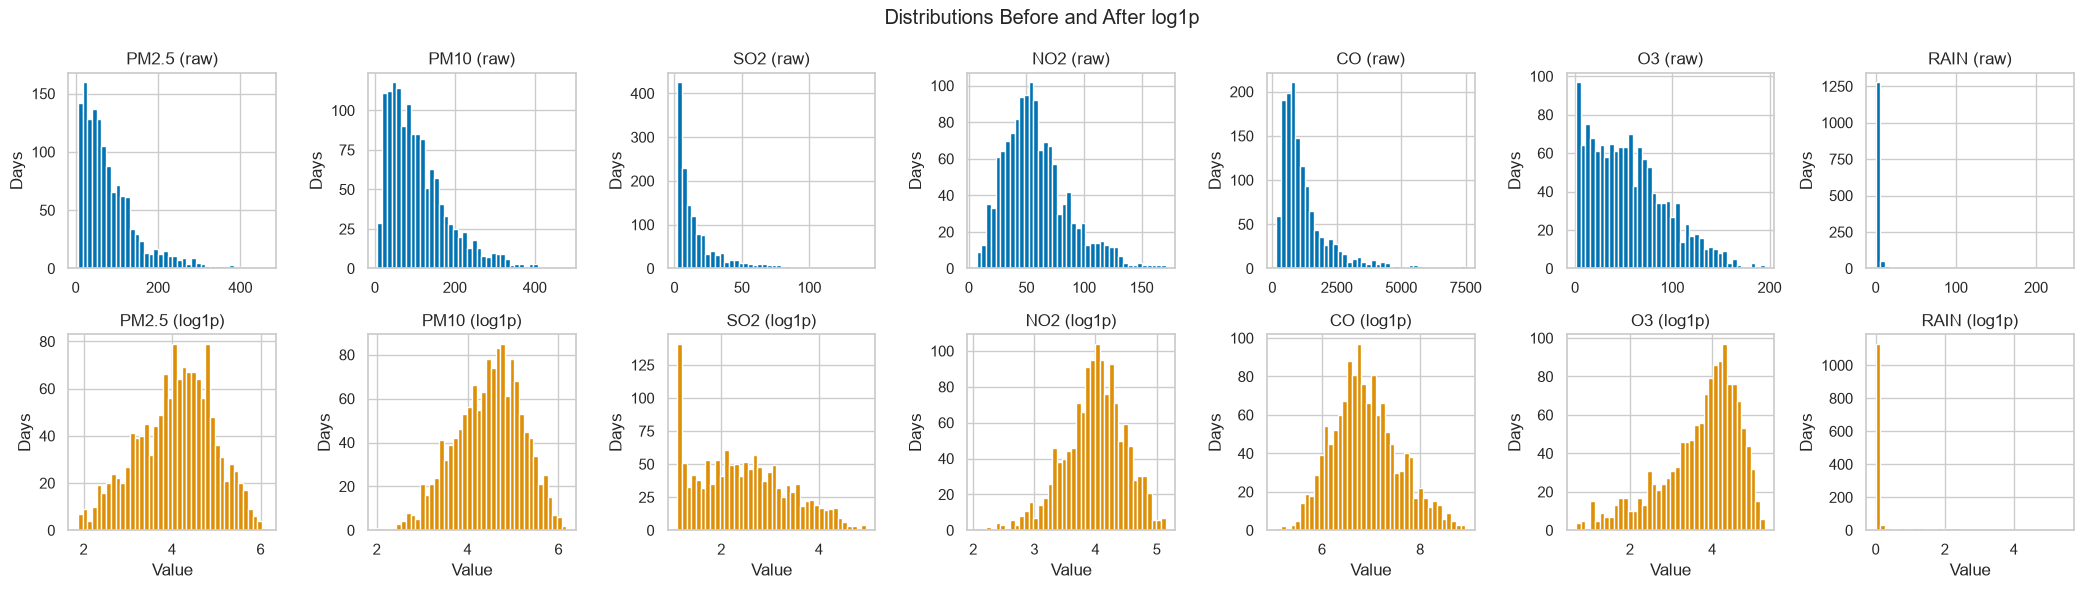

In [28]:
LOG_COLS = POLLUTANTS + ["RAIN"]

skew_before = X.skew().round(2)
X_model = X.copy()
X_model[LOG_COLS] = np.log1p(X_model[LOG_COLS])
skew_after = X_model.skew().round(2)
display(pd.DataFrame({"skew_before": skew_before, "skew_after": skew_after}))

fig, axes = plt.subplots(2, 7, figsize=(21, 6))
for i, col in enumerate(LOG_COLS):
    axes[0, i].hist(X[col], bins=40, color=PALETTE[0])
    axes[0, i].set_title(f"{col} (raw)")
    axes[0, i].set_ylabel("Days")
    axes[1, i].hist(X_model[col], bins=40, color=PALETTE[1])
    axes[1, i].set_title(f"{col} (log1p)")
    axes[1, i].set_xlabel("Value")
    axes[1, i].set_ylabel("Days")
fig.suptitle("Distributions Before and After log1p")
plt.tight_layout()
plt.show()

### 📝 Observation — Skewness

Before the transform, the most skewed pollutants were ___ (skew ___) and ___ (skew ___). After `log1p` they fell to ___ and ___, so the histograms look much more symmetric. RAIN remains highly skewed (___) because most days have no rain at all; it is kept because ___ .

### Correlation Between Clustering Features

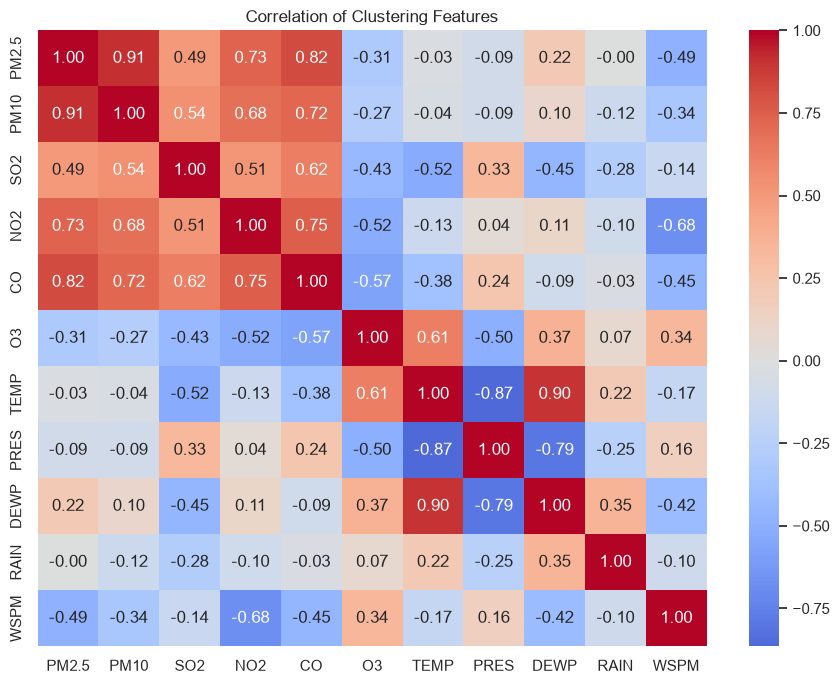

In [29]:
plt.figure(figsize=(9, 7))
sns.heatmap(X_model.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation of Clustering Features")
plt.tight_layout()
plt.show()

### 📝 Observation — Correlation

The strongest positive correlations are ___ – ___ (___) and ___ – ___ (___), which makes sense because ___. Temperature and dew point are ___ correlated (___). Ozone is ___ related to the other pollutants (___), consistent with ___ . Because some features are highly correlated, ___ (e.g. PCA later will compress them into fewer components).

## 5. Feature Scaling

`StandardScaler` puts all 11 features on mean 0, standard deviation 1. Without it, `CO` (hundreds) and `PRES` (about 1000) would dominate the Euclidean distance over `WSPM` or `RAIN` (single digits). Clustering has no train/test split, so the scaler is fitted on the full feature matrix — there is no test set to leak into.

> **Shared setup ends here.** The Hierarchical section reuses the same `X_scaled` so both algorithms are compared on identical data.

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)

print("Scaled shape:", X_scaled.shape)
print("Means  :", X_scaled.mean(axis=0).round(3))
print("Std dev:", X_scaled.std(axis=0).round(3))

Scaled shape: (1381, 11)
Means  : [-0.  0.  0. -0.  0.  0.  0.  0. -0. -0.  0.]
Std dev: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
